In [1]:
import os
import clip
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = "cuda"

# --- Load CLIP ---
print("Loading CLIP model...")
model, preprocess = clip.load("ViT-L/14", device=device)
model.eval()
print(f"Using: {torch.cuda.get_device_name(0)}")

Loading CLIP model...
Using: NVIDIA RTX A6000


In [2]:
import os

base_path = "dataset/bffhq/0.5pct"

class_0_path = os.path.join(base_path, "0")
class_1_path = os.path.join(base_path, "1")

len_0 = len(os.listdir(class_0_path))
len_1 = len(os.listdir(class_1_path))

print("Length of 0.5pct/0:", len_0)
print("Length of 0.5pct/1:", len_1)

Length of 0.5pct/0: 9600
Length of 0.5pct/1: 9600


In [3]:
# --- Dataset for flat folders (test/valid) ---
class BFFHQFlat(Dataset):
    def __init__(self, folder, transform):
        self.transform = transform
        self.samples = []
        for fname in sorted(os.listdir(folder)):
            if not fname.endswith(".png"):
                continue
            parts = fname.replace(".png", "").split("_")
            age    = int(parts[1])   # 0=young, 1=old    
            gender = int(parts[2])   # 0=female, 1=male
            self.samples.append((os.path.join(folder, fname), age, gender))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, age, gender = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return img, age, gender

# --- Dataset for 0/1 folders (train) ---
class BFFHQTrain(Dataset):
    def __init__(self, folder, transform):
        self.transform = transform
        self.samples = []
        for age_label in ["0", "1"]:          # 0=old, 1=young
            subdir = os.path.join(folder, age_label)
            if not os.path.exists(subdir):
                continue
            for fname in sorted(os.listdir(subdir)):
                if not fname.endswith(".png"):
                    continue
                parts = fname.replace(".png", "").split("_")
                age    = int(parts[1])   # from filename: 0=young, 1=old
                gender = int(parts[2])   # 0=female, 1=male
                path   = os.path.join(subdir, fname)
                self.samples.append((path, age, gender))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, age, gender = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return img, age, gender

In [4]:
# --- Single extraction function (works for both) ---
def extract(loader):
    all_embs, all_age, all_gender = [], [], []
    with torch.no_grad():
        for imgs, age, gender in loader:
            embs = model.encode_image(imgs.to(device))
            all_embs.append(embs.cpu())
            all_age.append(age)
            all_gender.append(gender)
    return torch.cat(all_embs), torch.cat(all_age).numpy(), torch.cat(all_gender).numpy()



# --- Run extraction ---
base = "dataset/bffhq"

print("Extracting test...")
test_ds  = BFFHQFlat(f"{base}/test", preprocess)
test_embs, test_age, test_gender = extract(DataLoader(test_ds, batch_size=512, num_workers=4))

print("Extracting valid...")
valid_ds  = BFFHQFlat(f"{base}/valid", preprocess)
valid_embs, valid_age, valid_gender = extract(DataLoader(valid_ds, batch_size=512, num_workers=4))

print("Extracting train (0.5pct)...")
train_ds  = BFFHQTrain(f"{base}/0.5pct", preprocess)
train_embs, train_age, train_gender = extract(DataLoader(train_ds, batch_size=512, num_workers=4))

# --- Extract 0(young) and 1(old) separately ---
print("Extracting train 0(young) (0.5pct)...")
young_0_embs, young_0_age, young_0_gender = extract(DataLoader(BFFHQFlat("dataset/bffhq/0.5pct/0", preprocess),batch_size=512, num_workers=4))

print("Extracting train 1(old) (0.5pct)...")
old_1_embs, old_1_age, old_1_gender = extract(DataLoader(BFFHQFlat("dataset/bffhq/0.5pct/1", preprocess), batch_size=512, num_workers=4))

# --- Extract align and conflict separately ---
# print("Extracting train align (1pct)...")
# align_embs, align_age, align_gender = extract(DataLoader(BFFHQTrain("dataset/bffhq/0.5pct", preprocess, subset="align"),batch_size=512, num_workers=4))

# print("Extracting train conflict (1pct)...")
# conflict_embs, conflict_age, conflict_gender = extract(DataLoader(BFFHQTrain("dataset/bffhq/0.5pct", preprocess, subset="conflict"), batch_size=512, num_workers=4))

Extracting test...


Extracting valid...
Extracting train (0.5pct)...
Extracting train 0(young) (0.5pct)...
Extracting train 1(old) (0.5pct)...


In [5]:
# --- Save ---
os.makedirs("0.5pct/embeddings", exist_ok=True)

# test / valid
torch.save(test_embs,  "0.5pct/embeddings/test_embs.pt")
torch.save(valid_embs, "0.5pct/embeddings/valid_embs.pt")
np.save("0.5pct/embeddings/test_age.npy",     test_age)
np.save("0.5pct/embeddings/test_gender.npy",  test_gender)
np.save("0.5pct/embeddings/valid_age.npy",    valid_age)
np.save("0.5pct/embeddings/valid_gender.npy", valid_gender)

# train combined
torch.save(train_embs, "0.5pct/embeddings/train_embs.pt")
np.save("0.5pct/embeddings/train_age.npy",    train_age)
np.save("0.5pct/embeddings/train_gender.npy", train_gender)



torch.save(young_0_embs,    "0.5pct/embeddings/young_0_embs.pt")
torch.save(old_1_embs, "0.5pct/embeddings/old_1_embs.pt")
np.save("0.5pct/embeddings/young_0_age.npy",       young_0_age)
np.save("0.5pct/embeddings/young_0_gender.npy",    young_0_gender)
np.save("0.5pct/embeddings/old_1_age.npy",    old_1_age)
np.save("0.5pct/embeddings/old_1_gender.npy", old_1_gender)

# align / conflict separately
# torch.save(align_embs,    "embeddings/0.5pct/align_embs.pt")
# torch.save(conflict_embs, "embeddings/0.5pct/conflict_embs.pt")
# np.save("embeddings/0.5pct/align_age.npy",       align_age)
# np.save("embeddings/0.5pct/align_gender.npy",    align_gender)
# np.save("embeddings/0.5pct/conflict_age.npy",    conflict_age)
# np.save("embeddings/0.5pct/conflict_gender.npy", conflict_gender)


print("All embeddings saved to embeddings/")

All embeddings saved to embeddings/


In [6]:
# --- Bias check ---
print("\n--- Bias check ---")
for split, age_l, gen_l in [
    ("test",     test_age,     test_gender),
    ("valid",    valid_age,    valid_gender),
    ("train",    train_age,    train_gender),
    # ("align",    align_age,    align_gender),
    # ("conflict", conflict_age, conflict_gender)
     ("young",    young_0_age,    young_0_gender),
    ("old", old_1_age, old_1_gender)
]:
    print(f"\n{split} (n={len(age_l)}):")
    for age, name in [(0, "young"), (1, "old")]:
        mask = age_l == age
        if mask.sum() == 0:
            continue
        male_pct = (gen_l[mask] == 1).mean() * 100
        print(f"  {name}: {male_pct:.1f}% male, {100-male_pct:.1f}% female  (n={mask.sum()})")


--- Bias check ---

test (n=1000):
  young: 50.0% male, 50.0% female  (n=500)
  old: 50.0% male, 50.0% female  (n=500)

valid (n=1000):
  young: 0.0% male, 100.0% female  (n=500)
  old: 100.0% male, 0.0% female  (n=500)

train (n=19200):
  young: 0.5% male, 99.5% female  (n=9600)
  old: 99.5% male, 0.5% female  (n=9600)

young (n=9600):
  young: 0.5% male, 99.5% female  (n=9600)

old (n=9600):
  old: 99.5% male, 0.5% female  (n=9600)


In [2]:
import torch
import numpy as np

# Load
train_embs  = torch.load("0.5pct/embeddings/train_embs.pt").float()
test_embs   = torch.load("0.5pct/embeddings/test_embs.pt").float()
valid_embs  = torch.load("0.5pct/embeddings/valid_embs.pt").float()
# align_embs  = torch.load("embeddings/align_embs.pt").float()
# conflict_embs = torch.load("embeddings/conflict_embs.pt").float()
young_0_embs=torch.load("0.5pct/embeddings/young_0_embs.pt").float()
old_1_embs=torch.load("0.5pct/embeddings/old_1_embs.pt").float()


young_0_age=np.load("0.5pct/embeddings/young_0_age.npy")
young_0_gender=np.load("0.5pct/embeddings/young_0_gender.npy")
old_1_age=np.load("0.5pct/embeddings/old_1_age.npy")
old_1_gender=np.load("0.5pct/embeddings/old_1_gender.npy")
train_age     = np.load("0.5pct/embeddings/train_age.npy")
train_gender  = np.load("0.5pct/embeddings/train_gender.npy")
test_age      = np.load("0.5pct/embeddings/test_age.npy")
test_gender   = np.load("0.5pct/embeddings/test_gender.npy")
valid_age     = np.load("0.5pct/embeddings/valid_age.npy")
valid_gender  = np.load("0.5pct/embeddings/valid_gender.npy")
# align_age     = np.load("0.5pct/embeddings/align_age.npy")
# align_gender  = np.load("0.5pct/embeddings/align_gender.npy")
# conflict_age  = np.load("0.5pct/embeddings/conflict_age.npy")
# conflict_gender = np.load("0.5pct/embeddings/conflict_gender.npy")

In [ ]:
print(train_embs.shape)
print(test_embs.shape)
print(valid_embs.shape)
# print(align_embs.shape)
# print(conflict_embs.shape)
print(young_0_embs.shape)
print(old_1_embs.shape)

torch.Size([19200, 768])
torch.Size([1000, 768])
torch.Size([1000, 768])
torch.Size([9600, 768])
torch.Size([9600, 768])


In [9]:
print(train_embs[(train_age==1) & (train_gender==1)][0].shape)

torch.Size([768])


In [10]:
# Mean vectors per group (more stable than single samples)
old_male    = train_embs[(train_age==1) & (train_gender==1)].mean(0)
old_female  = train_embs[(train_age==1) & (train_gender==0)].mean(0)
young_male  = train_embs[(train_age==0) & (train_gender==1)].mean(0)
young_female= train_embs[(train_age==0) & (train_gender==0)].mean(0)

def find_nearest(query_vec, embs, age_l, gender_l, top_k=5):
    query_norm = query_vec / query_vec.norm()
    embs_norm  = embs 
    sims       = embs_norm @ query_norm
    topk       = sims.topk(top_k)
    print(f"Top {top_k} nearest:")
    for sim, idx in zip(topk.values, topk.indices):
        a = "old"   if age_l[idx]==1    else "young"
        g = "male"  if gender_l[idx]==1 else "female"
        print(f"  idx={idx.item():5d}  {a} {g:8s}  sim={sim:.3f}")

# --- Try different arithmetic ---

# 1. old male - gender = old female?
print("\n1. old_male - (male - female):")
find_nearest(old_male - (young_male - young_female), train_embs, train_age, train_gender)

# 2. young female + age = old female?
print("\n2. young_female + (old - young):")
find_nearest(young_female + (old_male - young_male), train_embs, train_age, train_gender)

# 3. young male + age = old male?
print("\n3. young_male + (old - young):")
find_nearest(young_male + (old_female - young_female), train_embs, train_age, train_gender)


1. old_male - (male - female):
Top 5 nearest:
  idx= 7152  young female    sim=18.335
  idx= 4653  young female    sim=18.195
  idx= 1222  young female    sim=18.142
  idx= 2349  young female    sim=18.112
  idx= 4846  young female    sim=18.105

2. young_female + (old - young):
Top 5 nearest:
  idx= 7152  young female    sim=18.335
  idx= 4653  young female    sim=18.195
  idx= 1222  young female    sim=18.142
  idx= 2349  young female    sim=18.112
  idx= 4846  young female    sim=18.105

3. young_male + (old - young):
Top 5 nearest:
  idx=12609  old male      sim=18.592
  idx=18283  old male      sim=18.336
  idx=14904  old male      sim=18.294
  idx=12910  old male      sim=18.282
  idx=16382  old male      sim=18.196


In [11]:
# How far apart are the 4 group mean vectors?
import torch.nn.functional as F

groups = {
    "old_male":    old_male,
    "old_female":  old_female,
    "young_male":  young_male,
    "young_female":young_female,
}

print("Pairwise cosine similarities between group means:")
print(f"{'':15s}", end="")
for n in groups: print(f"{n:15s}", end="")
print()

for n1, v1 in groups.items():
    print(f"{n1:15s}", end="")
    for n2, v2 in groups.items():
        sim = F.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0)).item()
        print(f"{sim:15.3f}", end="")
    print()

Pairwise cosine similarities between group means:
               old_male       old_female     young_male     young_female   
old_male                 1.000          0.887          0.913          0.862
old_female               0.887          1.000          0.848          0.912
young_male               0.913          0.848          1.000          0.914
young_female             0.862          0.912          0.914          1.000


Saved similarity_heatmap.png


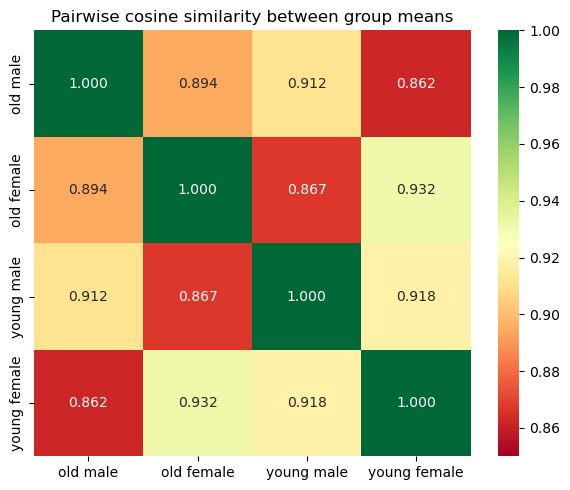

In [12]:
import seaborn as sns
import os
import matplotlib.pyplot as plt
os.makedirs("0.5pct", exist_ok=True)

matrix = torch.tensor([
    [1.000, 0.894, 0.912, 0.862],
    [0.894, 1.000, 0.867, 0.932],
    [0.912, 0.867, 1.000, 0.918],
    [0.862, 0.932, 0.918, 1.000],
])

labels = ["old male", "old female", "young male", "young female"]

plt.figure(figsize=(6, 5))
sns.heatmap(matrix.numpy(), annot=True, fmt=".3f",
            xticklabels=labels, yticklabels=labels,
            cmap="RdYlGn", vmin=0.85, vmax=1.0)
plt.title("Pairwise cosine similarity between group means")
plt.tight_layout()
plt.savefig("0.5pct/similarity_heatmap.png", dpi=150)
print("Saved similarity_heatmap.png")

Running t-SNE for train (19200 points)...
Running t-SNE for test (1000 points)...
Running t-SNE for valid (1000 points)...
Running t-SNE for young_0_embs (9600 points)...
Running t-SNE for old_1_embs (9600 points)...
Saved tsne_all_splits.png


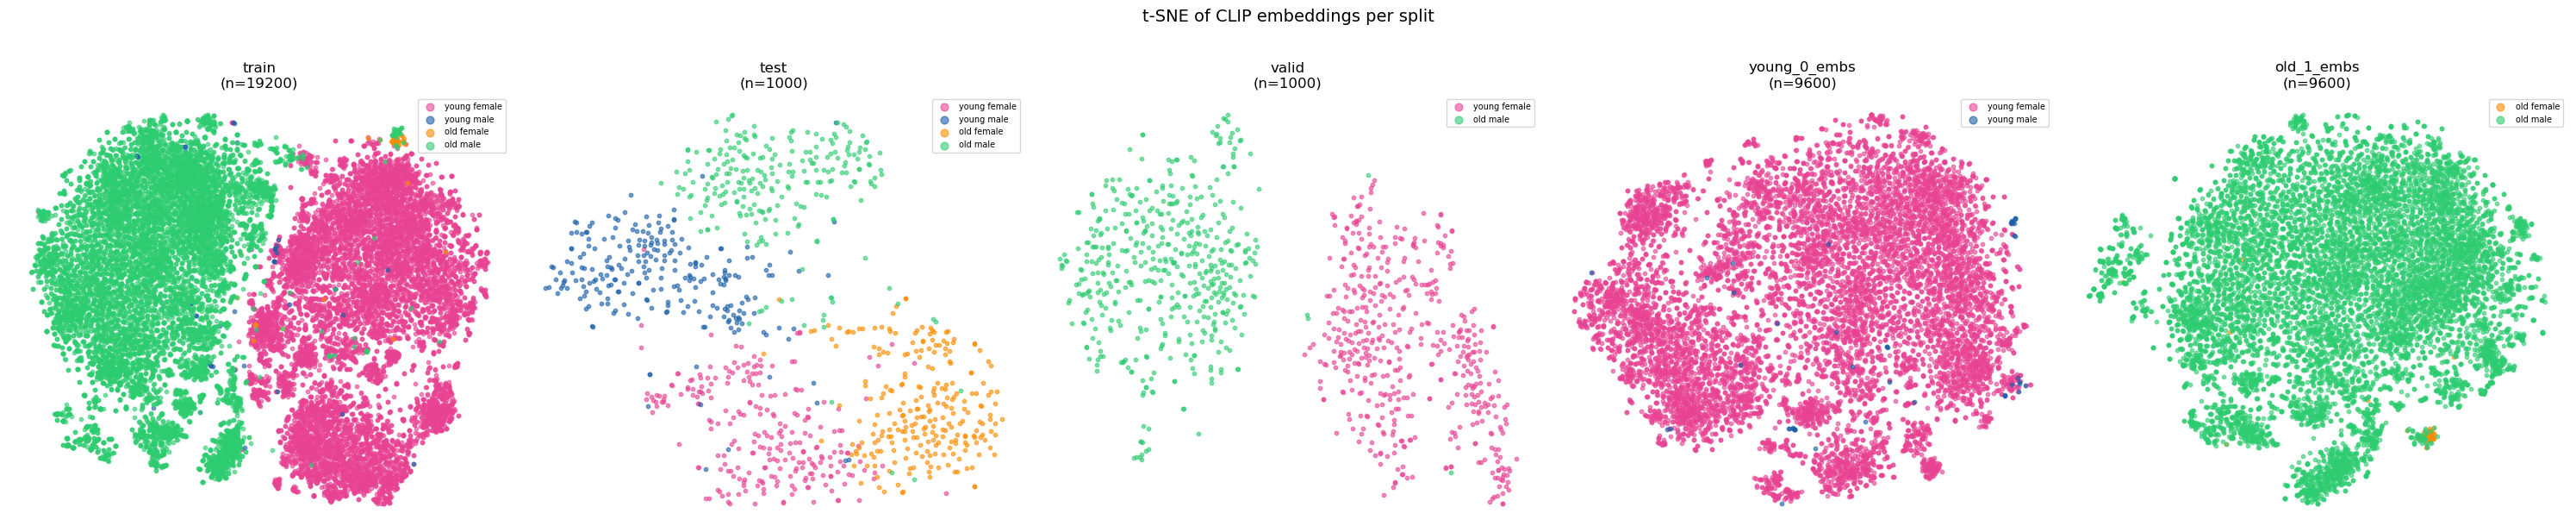

In [5]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393",      1: "#1A5FA8",    2: "#FF8C00",    3: "#2ECC71"}

splits = [
    ("train",    train_embs.numpy(),    train_age,    train_gender),
    ("test",     test_embs.numpy(),     test_age,     test_gender),
    ("valid",    valid_embs.numpy(),    valid_age,    valid_gender),
    # ("align",    align_embs.numpy(),    align_age,    align_gender),
    # ("conflict", conflict_embs.numpy(), conflict_age, conflict_gender),
    ("young_0_embs",    young_0_embs.numpy(),    young_0_age,    young_0_gender),
    ("old_1_embs", old_1_embs.numpy(), old_1_age, old_1_gender)
]

fig, axes = plt.subplots(1, 5, figsize=(30, 6))

for ax, (name, embs, age, gender) in zip(axes, splits):
    np.random.seed(42)
    n = len(embs)
    idx = np.random.choice(len(embs), n, replace=False)
    embs_sub  = embs[idx]
    age_sub   = age[idx]
    gender_sub = gender[idx]
    group_sub  = age_sub * 2 + gender_sub

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs_sub)

    for g, gname in group_names.items():
        mask = group_sub == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=10, alpha=0.6)

    ax.set_title(f"{name}\n(n={n})", fontsize=12)
    ax.legend(fontsize=7, markerscale=2)
    ax.axis("off")

plt.suptitle("t-SNE of CLIP embeddings per split", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("0.5pct/tsne/tsne_all_splits.png", dpi=150, bbox_inches="tight")
print("Saved tsne_all_splits.png")

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs("0.5pct/tsne", exist_ok=True)

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393",      1: "#1A5FA8",    2: "#FF8C00",    3: "#2ECC71"}

splits = [
    ("train",    train_embs.numpy(),    train_age,    train_gender),
    ("test",     test_embs.numpy(),     test_age,     test_gender),
    ("valid",    valid_embs.numpy(),    valid_age,    valid_gender),
    # ("align",    align_embs.numpy(),    align_age,    align_gender),
    # ("conflict", conflict_embs.numpy(), conflict_age, conflict_gender),
    ("young_0_embs",    young_0_embs.numpy(),    young_0_age,    young_0_gender),
    ("old_1_embs", old_1_embs.numpy(), old_1_age, old_1_gender)
]

for split_name, embs, age, gender in splits:
    np.random.seed(42)
    n=len(embs)
    idx = np.random.choice(len(embs), n, replace=False)
    embs_sub   = embs[idx]
    age_sub    = age[idx]
    gender_sub = gender[idx]
    group_sub  = age_sub * 2 + gender_sub

    print(f"Running t-SNE for {split_name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs_sub)

    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group_sub == g
        if mask.sum() == 0:
            continue
        plt.scatter(e2d[mask, 0], e2d[mask, 1],
                    c=colors[g], label=gname, s=15, alpha=0.7)

    plt.title(f"t-SNE — {split_name} (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"0.5pct/tsne/tsne_{split_name}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{split_name}.png")

print("\nAll plots saved!")

Running t-SNE for train (19200 points)...
Saved tsne_train.png
Running t-SNE for test (1000 points)...
Saved tsne_test.png
Running t-SNE for valid (1000 points)...
Saved tsne_valid.png
Running t-SNE for young_0_embs (9600 points)...
Saved tsne_young_0_embs.png
Running t-SNE for old_1_embs (9600 points)...
Saved tsne_old_1_embs.png

All plots saved!


# Debiasing Embeddings

In [14]:
# Check how spread out each group is
for (a, g, name) in [(1,1,"old male"), (1,0,"old female"), 
                      (0,1,"young male"), (0,0,"young female")]:
    mask = (train_age==a) & (train_gender==g)
    group = train_embs[mask]
    print(f"{name:15s}  n={mask.sum():5d}  "
          f"mean_norm={group.norm(dim=-1).mean():.3f}  "
          f"intra_sim={( (group/group.norm(dim=-1,keepdim=True)) @ (group/group.norm(dim=-1,keepdim=True)).T ).mean():.3f}")

old male         n= 9552  mean_norm=18.253  intra_sim=0.606
old female       n=   48  mean_norm=18.804  intra_sim=0.736
young male       n=   48  mean_norm=19.080  intra_sim=0.664
young female     n= 9552  mean_norm=19.370  intra_sim=0.688


In [15]:
# # Step 1 — Build bipartite similarity graph
# import torch
# import numpy as np

# # Normalize embeddings
# align_norm    = align_embs    / align_embs.norm(dim=-1, keepdim=True)
# conflict_norm = conflict_embs / conflict_embs.norm(dim=-1, keepdim=True)

# # Similarity matrix between ALL align and conflict samples
# # shape: (19008, 192)
# sim_matrix = align_norm @ conflict_norm.T
# print(f"Similarity matrix shape: {sim_matrix.shape}")
# print(f"Mean similarity: {sim_matrix.mean():.3f}")
# print(f"Max similarity:  {sim_matrix.max():.3f}")



# # Step 2 — Find cross-class pairs (align class X ↔ conflict class Y)
# # young_female(align) ↔ old_female(conflict)
# yf_align_idx    = np.where((align_age==0) & (align_gender==0))[0]  # young female align
# of_conflict_idx = np.where((conflict_age==1) & (conflict_gender==0))[0]  # old female conflict

# sim_yf_of = sim_matrix[np.ix_(yf_align_idx, of_conflict_idx)]
# print(f"\nyoung_female(align) ↔ old_female(conflict)")
# print(f"  shape: {sim_yf_of.shape}")
# print(f"  mean sim: {sim_yf_of.mean():.3f}")
# print(f"  max sim:  {sim_yf_of.max():.3f}")

# # old_male(align) ↔ young_male(conflict)
# om_align_idx    = np.where((align_age==1) & (align_gender==1))[0]
# ym_conflict_idx = np.where((conflict_age==0) & (conflict_gender==1))[0]

# sim_om_ym = sim_matrix[np.ix_(om_align_idx, ym_conflict_idx)]
# print(f"\nold_male(align) ↔ young_male(conflict)")
# print(f"  shape: {sim_om_ym.shape}")
# print(f"  mean sim: {sim_om_ym.mean():.3f}")
# print(f"  max sim:  {sim_om_ym.max():.3f}")


# # young_female(align) ↔ young_male(conflict of same class)
# yf_align_idx    = np.where((align_age==0) & (align_gender==0))[0]
# ym_conflict_idx = np.where((conflict_age==0) & (conflict_gender==1))[0]

# sim_om_ym = sim_matrix[np.ix_(yf_align_idx, ym_conflict_idx)]
# print(f"young_female(align) ↔ young_male(conflict of same class)")
# print(f"  shape: {sim_om_ym.shape}")
# print(f"  mean sim: {sim_om_ym.mean():.3f}")
# print(f"  max sim:  {sim_om_ym.max():.3f}")


# # old_female(align) ↔ old_male(conflict of same class)
# om_align_idx    = np.where((align_age==1) & (align_gender==1))[0]
# of_conflict_idx = np.where((conflict_age==1) & (conflict_gender==0))[0]

# sim_om_ym = sim_matrix[np.ix_(om_align_idx, of_conflict_idx)]
# print(f"old_female(align) ↔ old_male(conflict of same class)")
# print(f"  shape: {sim_om_ym.shape}")
# print(f"  mean sim: {sim_om_ym.mean():.3f}")
# print(f"  max sim:  {sim_om_ym.max():.3f}")

## Similarity Threshold = 0.8

In [ ]:
import time

# Load age-based embeddings

old_embs   = old_1_embs   # all old (male+female)
young_embs = young_0_embs   # all young (male+female)

print(f"old:   {old_embs.shape}")
print(f"young: {young_embs.shape}")

# Normalize
old_norm   = old_embs   / old_embs.norm(dim=-1, keepdim=True)
young_norm = young_embs / young_embs.norm(dim=-1, keepdim=True)

start=time.time()
# Similarity matrix old↔young (9600 x 9600)
print("Computing similarity matrix...")
sim_matrix = old_norm @ young_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.80  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end=time.time()
print((end-start)/60,"minutes")

old:   torch.Size([9600, 768])
young: torch.Size([9600, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([9600, 9600])
mean=0.555  max=0.933  min=0.102

Pairs with sim > 0.8: 88993
sim range: 0.800 - 0.933
mean sim of selected pairs: 0.816
0.007451327641805013 minutes


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (old↔young, sim>0.8): {n_pairs}")
neg_e1      = old_embs[old_idx]
neg_e2      = young_embs[young_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) — no gender labels ---
n_pos_each = n_pairs // 2

# young↔young
ym_idx1      = torch.randint(0, len(young_embs), (n_pos_each,))
ym_idx2      = torch.randint(0, len(young_embs), (n_pos_each,))
young_pos_e1 = young_embs[ym_idx1]
young_pos_e2 = young_embs[ym_idx2]

# old↔old
om_idx1    = torch.randint(0, len(old_embs), (n_pos_each,))
om_idx2    = torch.randint(0, len(old_embs), (n_pos_each,))
old_pos_e1 = old_embs[om_idx1]
old_pos_e2 = old_embs[om_idx2]

pos_e1      = torch.cat([young_pos_e1, old_pos_e1])
pos_e2      = torch.cat([young_pos_e2, old_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (old↔young):             {(all_labels==0).sum()}")
print(f"  pull (young↔young + old↔old): {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(young_embs[:1000].to(device))
    p4 = model_head(young_embs[1000:2000].to(device))
    p5 = model_head(old_embs[:1000].to(device))
    p6 = model_head(old_embs[1000:2000].to(device))
print(f"Before training:")
print(f"  push_sim(old↔young):   {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(young↔young): {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(old↔old):     {F.cosine_similarity(p5,p6).mean():.3f}")

start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(young_embs[:1000].to(device))
            p4 = model_head(young_embs[1000:2000].to(device))
            p5 = model_head(old_embs[:1000].to(device))
            p6 = model_head(old_embs[1000:2000].to(device))
            push_sim   = F.cosine_similarity(p1, p2).mean().item()
            pull_young = F.cosine_similarity(p3, p4).mean().item()
            pull_old   = F.cosine_similarity(p5, p6).mean().item()
            w_diff     = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_young={pull_young:.3f}  pull_old={pull_old:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.8).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (old↔young, sim>0.8): 88993

Total pairs: 177985
  push (old↔young):             88993
  pull (young↔young + old↔old): 88992
Before training:
  push_sim(old↔young):   0.815
  pull_sim(young↔young): 0.690
  pull_sim(old↔old):     0.609

Training...
  epoch   0  loss=0.0731  push_sim=0.142  pull_young=0.858  pull_old=0.867  W_diff=0.00770
  epoch  10  loss=0.0014  push_sim=0.071  pull_young=0.906  pull_old=0.899  W_diff=0.00757
  epoch  20  loss=0.0006  push_sim=0.143  pull_young=0.922  pull_old=0.908  W_diff=0.00619
  epoch  30  loss=0.0002  push_sim=0.091  pull_young=0.925  pull_old=0.915  W_diff=0.00517
  epoch  40  loss=0.0001  push_sim=0.096  pull_young=0.926  pull_old=0.914  W_diff=0.00465
Done!
10.4 minutes


In [19]:
model_head.eval()
with torch.no_grad():
    # Project all embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()

    # Normalize
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    old_norm        = old_embs   / old_embs.norm(dim=-1, keepdim=True)
    young_norm      = young_embs / young_embs.norm(dim=-1, keepdim=True)

    # Push: old↔young similarity
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before = old_norm      @ young_norm.T

    # Pull: within same age group
    # young↔young
    sim_yy_before = young_norm      @ young_norm.T
    sim_yy_after  = young_proj_norm @ young_proj_norm.T
    # old↔old
    sim_oo_before = old_norm      @ old_norm.T
    sim_oo_after  = old_proj_norm @ old_proj_norm.T

    # Exclude diagonal (self similarity = 1)
    mask = ~torch.eye(len(old_embs), dtype=bool)
    mask_y = ~torch.eye(len(young_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (old↔young) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.8: {(sim_before_flat>0.8).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.8: {(sim_after_flat>0.8).sum()}")

print("\nPULL effect (young↔young) — want higher:")
print(f"  BEFORE: mean={sim_yy_before[mask_y].mean():.3f}  "
      f"min={sim_yy_before[mask_y].min():.3f}")
print(f"  AFTER:  mean={sim_yy_after[mask_y].mean():.3f}  "
      f"min={sim_yy_after[mask_y].min():.3f}")

print("\nPULL effect (old↔old) — want higher:")
print(f"  BEFORE: mean={sim_oo_before[mask].mean():.3f}  "
      f"min={sim_oo_before[mask].min():.3f}")
print(f"  AFTER:  mean={sim_oo_after[mask].mean():.3f}  "
      f"min={sim_oo_after[mask].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (old↔young) — want lower:
  BEFORE: mean=0.555  max=0.933  >0.8: 88993
  AFTER:  mean=0.232  max=0.950  >0.8: 9578

PULL effect (young↔young) — want higher:
  BEFORE: mean=0.688  min=0.188
  AFTER:  mean=0.927  min=0.360

PULL effect (old↔old) — want higher:
  BEFORE: mean=0.606  min=0.157
  AFTER:  mean=0.914  min=0.326
W_diff from identity: 0.00454


In [24]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")
print("Saved!")

Saved!


In [25]:
train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")

/tmp/ipykernel_3247600/4219214454.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
/tmp/

In [26]:
print(f"train_proj: {train_proj.shape}")  # should be (19200, 768)
print(f"test_proj:  {test_proj.shape}")   # should be (1000, 768)
print(f"valid_proj: {valid_proj.shape}")  # should be (1000, 768)

train_proj: torch.Size([19200, 768])
test_proj:  torch.Size([1000, 768])
valid_proj: torch.Size([1000, 768])


In [27]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 90.8%
  young female  : 100.0%
  young male    : 85.6%
  old female  : 78.0%
  old male    : 99.6%
  worst: 78.0%  best: 100.0%  gap: 22.0%

  DEBIASED (linear push)
Overall accuracy: 90.1%
  young female  : 100.0%
  young male    : 84.0%
  old female  : 76.8%
  old male    : 99.6%
  worst: 76.8%  best: 100.0%  gap: 23.2%


/tmp/ipykernel_3247600/1953000446.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_head.load_state_dict(torch.load("0.5pct/push_pull/Projection_heads/projection_he

Running t-SNE for train (proj) (19200 points)...
Running t-SNE for test (proj) (1000 points)...
Running t-SNE for valid (proj) (1000 points)...
Running t-SNE for old (proj) (9600 points)...
Running t-SNE for young (proj) (9600 points)...
Saved!


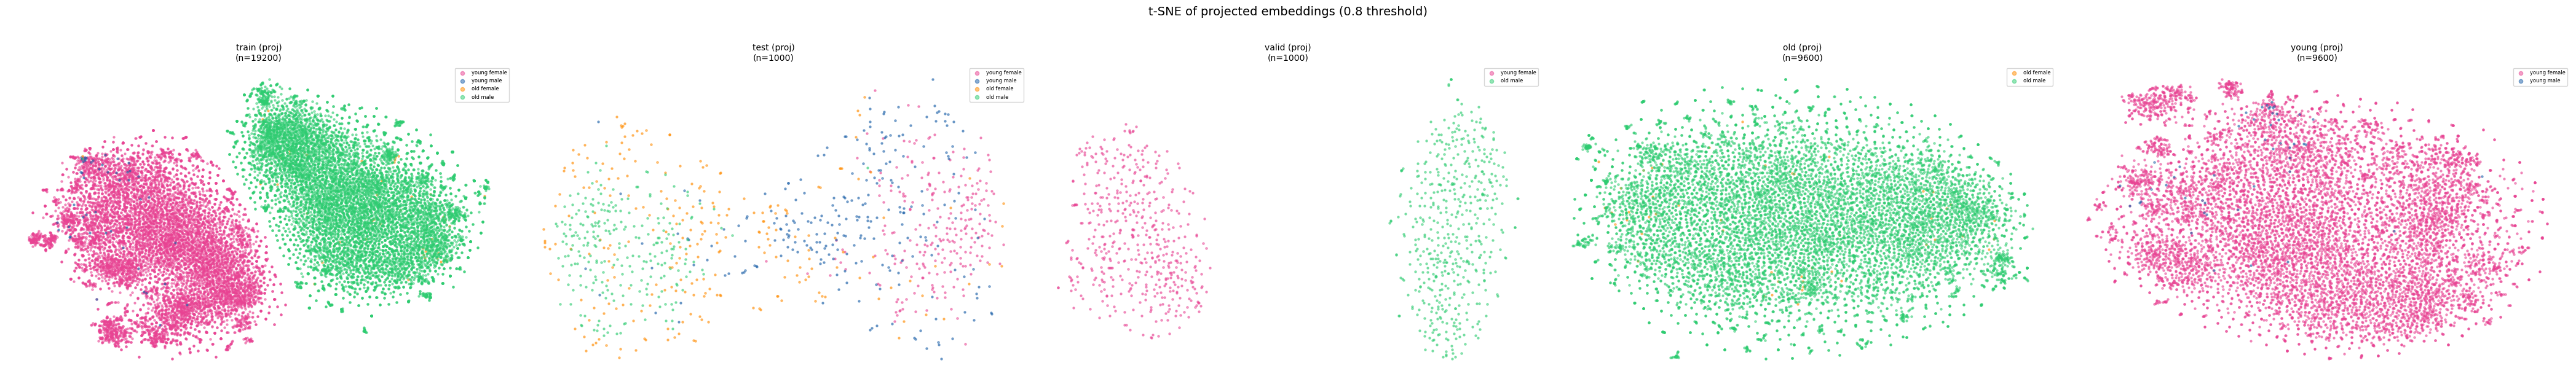

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("0.5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)
    
device     = "cuda"
model_head  = LinearDebias().to(device)  
model_head.load_state_dict(torch.load("0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.8).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",    project(train_embs),    train_age,    train_gender),
    ("test (proj)",     project(test_embs),      test_age,     test_gender),
    ("valid (proj)",    project(valid_embs),     valid_age,    valid_gender),
    # ("align (proj)",    project(align_embs),     align_age,    align_gender),
    # ("conflict (proj)", project(conflict_embs),  conflict_age, conflict_gender),
    ("old (proj)",      project(old_1_embs),       old_1_age,    old_1_gender),
    ("young (proj)",    project(young_0_embs),     young_0_age,  young_0_gender),
]

# 5 splits → 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(42, 6))

for ax, (name, embs, age, gender) in zip(axes, splits):
    group = age * 2 + gender
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

plt.suptitle("t-SNE of projected embeddings (0.8 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("0.5pct/push_pull/tsne/tsne_projected_all_splits(0.8).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [29]:
model_head.eval()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    # ("align",    align_embs,     align_age,    align_gender),
    # ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]

for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()   # original
    proj = project(embs_tensor)        # projected

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # # Save original
    # plt.figure(figsize=(7, 6))
    # for g, gname in group_names.items():
    #     mask = group == g
    #     if mask.sum() == 0: continue
    #     plt.scatter(orig_2d[mask, 0], orig_2d[mask, 1],
    #                 c=colors[g], label=gname, s=5, alpha=0.6)
    # plt.title(f"{name} — original (n={n})", fontsize=13)
    # plt.legend(fontsize=9, markerscale=2)
    # plt.axis("off")
    # plt.tight_layout()
    # plt.savefig(f"0.5pct/tsne/tsne_{name}_original.png", dpi=150, bbox_inches="tight")
    # plt.close()
    # print(f"Saved tsne_{name}_original.png")

    # Save projected
    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0: continue
        plt.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
                    c=colors[g], label=gname, s=5, alpha=0.6)
    plt.title(f"{name} — projected (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_projected(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_projected(0.8).png")

t-SNE original  train (19200 points)...


t-SNE projected train (19200 points)...
Saved tsne_train_projected(0.8).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_projected(0.8).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_projected(0.8).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_projected(0.8).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_projected(0.8).png


In [30]:
model_head.eval()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    # ("align",    align_embs,     align_age,    align_gender),
    # ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]

for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0: continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.8).png")

t-SNE original  train (19200 points)...
t-SNE projected train (19200 points)...
Saved tsne_train_orig_vs_proj(0.8).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_orig_vs_proj(0.8).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_orig_vs_proj(0.8).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_orig_vs_proj(0.8).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_orig_vs_proj(0.8).png


## Similarity Threshold = 0.7

In [3]:
import time

old_embs   = old_1_embs   # all old (male+female)
young_embs = young_0_embs   # all young (male+female)

print(f"old:   {old_embs.shape}")
print(f"young: {young_embs.shape}")

# Normalize
old_norm   = old_embs   / old_embs.norm(dim=-1, keepdim=True)
young_norm = young_embs / young_embs.norm(dim=-1, keepdim=True)

start = time.time()

# Similarity matrix old↔young (9600 x 9600)
print("Computing similarity matrix...")
sim_matrix = old_norm @ young_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.70  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print((end-start)/60,"minutes")

old:   torch.Size([9600, 768])
young: torch.Size([9600, 768])
Computing similarity matrix...


sim_matrix shape: torch.Size([9600, 9600])
mean=0.555  max=0.933  min=0.102

Pairs with sim > 0.7: 5725019
sim range: 0.700 - 0.933
mean sim of selected pairs: 0.730
0.013784197966257732 minutes


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (old↔young, sim>0.7): {n_pairs}")
neg_e1      = old_embs[old_idx]
neg_e2      = young_embs[young_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) — no gender labels ---
n_pos_each = n_pairs // 2

# young↔young
ym_idx1      = torch.randint(0, len(young_embs), (n_pos_each,))
ym_idx2      = torch.randint(0, len(young_embs), (n_pos_each,))
young_pos_e1 = young_embs[ym_idx1]
young_pos_e2 = young_embs[ym_idx2]

# old↔old
om_idx1    = torch.randint(0, len(old_embs), (n_pos_each,))
om_idx2    = torch.randint(0, len(old_embs), (n_pos_each,))
old_pos_e1 = old_embs[om_idx1]
old_pos_e2 = old_embs[om_idx2]

pos_e1      = torch.cat([young_pos_e1, old_pos_e1])
pos_e2      = torch.cat([young_pos_e2, old_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (old↔young):             {(all_labels==0).sum()}")
print(f"  pull (young↔young + old↔old): {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(young_embs[:1000].to(device))
    p4 = model_head(young_embs[1000:2000].to(device))
    p5 = model_head(old_embs[:1000].to(device))
    p6 = model_head(old_embs[1000:2000].to(device))
print(f"Before training:")
print(f"  push_sim(old↔young):   {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(young↔young): {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(old↔old):     {F.cosine_similarity(p5,p6).mean():.3f}")

start = time.time()
print("\nTraining...")
for epoch in range(5):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    model_head.eval()
    with torch.no_grad():
        p1 = model_head(neg_e1[:1000].to(device))
        p2 = model_head(neg_e2[:1000].to(device))
        p3 = model_head(young_embs[:1000].to(device))
        p4 = model_head(young_embs[1000:2000].to(device))
        p5 = model_head(old_embs[:1000].to(device))
        p6 = model_head(old_embs[1000:2000].to(device))
        push_sim   = F.cosine_similarity(p1, p2).mean().item()
        pull_young = F.cosine_similarity(p3, p4).mean().item()
        pull_old   = F.cosine_similarity(p5, p6).mean().item()
        w_diff     = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
    print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
            f"push_sim={push_sim:.3f}  "
            f"pull_young={pull_young:.3f}  pull_old={pull_old:.3f}  "
            f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.7).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (old↔young, sim>0.7): 5725019

Total pairs: 11450037
  push (old↔young):             5725019
  pull (young↔young + old↔old): 5725018
Before training:
  push_sim(old↔young):   0.745
  pull_sim(young↔young): 0.690
  pull_sim(old↔old):     0.609

Training...
  epoch   0  loss=0.0015  push_sim=-0.257  pull_young=0.966  pull_old=0.964  W_diff=0.00267
  epoch  10  loss=0.0001  push_sim=-0.207  pull_young=0.974  pull_old=0.968  W_diff=0.00214
  epoch  20  loss=0.0001  push_sim=-0.253  pull_young=0.971  pull_old=0.966  W_diff=0.00199
  epoch  30  loss=0.0000  push_sim=-0.238  pull_young=0.973  pull_old=0.971  W_diff=0.00179
  epoch  40  loss=0.0000  push_sim=-0.243  pull_young=0.978  pull_old=0.976  W_diff=0.00155
Done!
863.0 minutes


In [ ]:
model_head.eval()
with torch.no_grad():
    # Project all embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()

    # Normalize
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    old_norm        = old_embs   / old_embs.norm(dim=-1, keepdim=True)
    young_norm      = young_embs / young_embs.norm(dim=-1, keepdim=True)

    # Push: old↔young similarity
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before = old_norm      @ young_norm.T

    # Pull: within same age group
    # young↔young
    sim_yy_before = young_norm      @ young_norm.T
    sim_yy_after  = young_proj_norm @ young_proj_norm.T
    # old↔old
    sim_oo_before = old_norm      @ old_norm.T
    sim_oo_after  = old_proj_norm @ old_proj_norm.T

    # Exclude diagonal (self similarity = 1)
    mask = ~torch.eye(len(old_embs), dtype=bool)
    mask_y = ~torch.eye(len(young_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (old↔young) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.7: {(sim_before_flat>0.7).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.7: {(sim_after_flat>0.7).sum()}")

print("\nPULL effect (young↔young) — want higher:")
print(f"  BEFORE: mean={sim_yy_before[mask_y].mean():.3f}  "
      f"min={sim_yy_before[mask_y].min():.3f}")
print(f"  AFTER:  mean={sim_yy_after[mask_y].mean():.3f}  "
      f"min={sim_yy_after[mask_y].min():.3f}")

print("\nPULL effect (old↔old) — want higher:")
print(f"  BEFORE: mean={sim_oo_before[mask].mean():.3f}  "
      f"min={sim_oo_before[mask].min():.3f}")
print(f"  AFTER:  mean={sim_oo_after[mask].mean():.3f}  "
      f"min={sim_oo_after[mask].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (old↔young) — want lower:
  BEFORE: mean=0.555  max=0.933  >0.7: 5725019
  AFTER:  mean=-0.142  max=0.625  >0.7: 0

PULL effect (young↔young) — want higher:
  BEFORE: mean=0.688  min=0.188
  AFTER:  mean=0.987  min=0.769

PULL effect (old↔old) — want higher:
  BEFORE: mean=0.606  min=0.157
  AFTER:  mean=0.985  min=0.753
W_diff from identity: 0.00137


In [ ]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj(0.7).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj(0.7).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj(0.7).pt")
print("Saved!")

Saved!


In [ ]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj(0.7).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj(0.7).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj(0.7).pt")
def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()


def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

  BASELINE
Overall accuracy: 90.8%
  young female  : 100.0%
  young male    : 85.6%
  old female  : 78.0%
  old male    : 99.6%
  worst: 78.0%  best: 100.0%  gap: 22.0%

  DEBIASED (linear push)
Overall accuracy: 89.9%
  young female  : 99.6%
  young male    : 84.0%
  old female  : 76.4%
  old male    : 99.6%
  worst: 76.4%  best: 99.6%  gap: 23.2%


## Similarity Threshold = 0.9

In [33]:
# Find pairs with similarity > threshold k
k_threshold = 0.90  # only push very similar pairs

start = time.time()

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")
end = time.time()
print((end-start)/60,"minutes")


Pairs with sim > 0.9: 61
sim range: 0.900 - 0.933
mean sim of selected pairs: 0.909
0.0039378921190897625 minutes


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (old↔young, sim>0.9): {n_pairs}")
neg_e1      = old_embs[old_idx]
neg_e2      = young_embs[young_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) — no gender labels ---
n_pos_each = n_pairs // 2

# young↔young
ym_idx1      = torch.randint(0, len(young_embs), (n_pos_each,))
ym_idx2      = torch.randint(0, len(young_embs), (n_pos_each,))
young_pos_e1 = young_embs[ym_idx1]
young_pos_e2 = young_embs[ym_idx2]

# old↔old
om_idx1    = torch.randint(0, len(old_embs), (n_pos_each,))
om_idx2    = torch.randint(0, len(old_embs), (n_pos_each,))
old_pos_e1 = old_embs[om_idx1]
old_pos_e2 = old_embs[om_idx2]

pos_e1      = torch.cat([young_pos_e1, old_pos_e1])
pos_e2      = torch.cat([young_pos_e2, old_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (old↔young):             {(all_labels==0).sum()}")
print(f"  pull (young↔young + old↔old): {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(young_embs[:1000].to(device))
    p4 = model_head(young_embs[1000:2000].to(device))
    p5 = model_head(old_embs[:1000].to(device))
    p6 = model_head(old_embs[1000:2000].to(device))
print(f"Before training:")
print(f"  push_sim(old↔young):   {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(young↔young): {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(old↔old):     {F.cosine_similarity(p5,p6).mean():.3f}")

start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(young_embs[:1000].to(device))
            p4 = model_head(young_embs[1000:2000].to(device))
            p5 = model_head(old_embs[:1000].to(device))
            p6 = model_head(old_embs[1000:2000].to(device))
            push_sim   = F.cosine_similarity(p1, p2).mean().item()
            pull_young = F.cosine_similarity(p3, p4).mean().item()
            pull_old   = F.cosine_similarity(p5, p6).mean().item()
            w_diff     = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_young={pull_young:.3f}  pull_old={pull_old:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.9).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (old↔young, sim>0.9): 61



Total pairs: 121
  push (old↔young):             61
  pull (young↔young + old↔old): 60
Before training:
  push_sim(old↔young):   0.909
  pull_sim(young↔young): 0.690
  pull_sim(old↔old):     0.609

Training...
  epoch   0  loss=0.5425  push_sim=0.909  pull_young=0.694  pull_old=0.616  W_diff=0.00010
  epoch  10  loss=0.4645  push_sim=0.909  pull_young=0.735  pull_old=0.679  W_diff=0.00102
  epoch  20  loss=0.4156  push_sim=0.909  pull_young=0.762  pull_old=0.721  W_diff=0.00169
  epoch  30  loss=0.3924  push_sim=0.905  pull_young=0.773  pull_old=0.740  W_diff=0.00204
  epoch  40  loss=0.3838  push_sim=0.902  pull_young=0.775  pull_old=0.744  W_diff=0.00216
Done!
0.0 minutes


In [35]:
model_head.eval()
with torch.no_grad():
    # Project all embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()

    # Normalize
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    old_norm        = old_embs   / old_embs.norm(dim=-1, keepdim=True)
    young_norm      = young_embs / young_embs.norm(dim=-1, keepdim=True)

    # Push: old↔young similarity
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before = old_norm      @ young_norm.T

    # Pull: within same age group
    # young↔young
    sim_yy_before = young_norm      @ young_norm.T
    sim_yy_after  = young_proj_norm @ young_proj_norm.T
    # old↔old
    sim_oo_before = old_norm      @ old_norm.T
    sim_oo_after  = old_proj_norm @ old_proj_norm.T

    # Exclude diagonal (self similarity = 1)
    mask = ~torch.eye(len(old_embs), dtype=bool)
    mask_y = ~torch.eye(len(young_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (old↔young) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.9: {(sim_before_flat>0.9).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.9: {(sim_after_flat>0.9).sum()}")

print("\nPULL effect (young↔young) — want higher:")
print(f"  BEFORE: mean={sim_yy_before[mask_y].mean():.3f}  "
      f"min={sim_yy_before[mask_y].min():.3f}")
print(f"  AFTER:  mean={sim_yy_after[mask_y].mean():.3f}  "
      f"min={sim_yy_after[mask_y].min():.3f}")

print("\nPULL effect (old↔old) — want higher:")
print(f"  BEFORE: mean={sim_oo_before[mask].mean():.3f}  "
      f"min={sim_oo_before[mask].min():.3f}")
print(f"  AFTER:  mean={sim_oo_after[mask].mean():.3f}  "
      f"min={sim_oo_after[mask].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (old↔young) — want lower:
  BEFORE: mean=0.555  max=0.933  >0.9: 61
  AFTER:  mean=0.670  max=0.936  >0.9: 192

PULL effect (young↔young) — want higher:
  BEFORE: mean=0.688  min=0.188
  AFTER:  mean=0.774  min=0.309

PULL effect (old↔old) — want higher:
  BEFORE: mean=0.606  min=0.157
  AFTER:  mean=0.743  min=0.369
W_diff from identity: 0.00217


In [38]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj(0.9).pt")
torch.save(valid_proj  ,  "0.5pct/push_pull/embeddings/valid_proj(0.9).pt")
torch.save(test_proj, "0.5pct/push_pull/embeddings/test_proj(0.9).pt")
print("Saved!")

Saved!


In [39]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj(0.9).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj(0.9).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj(0.9).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3247600/3760187288.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj(0.9).pt")
/tmp/ipykernel_


  BASELINE
Overall accuracy: 90.8%
  young female  : 100.0%
  young male    : 85.6%
  old female  : 78.0%
  old male    : 99.6%
  worst: 78.0%  best: 100.0%  gap: 22.0%

  DEBIASED (linear push)
Overall accuracy: 83.2%
  young female  : 99.6%
  young male    : 65.2%
  old female  : 68.4%
  old male    : 99.6%
  worst: 65.2%  best: 99.6%  gap: 34.4%


## Similarity Threshold = 0.75

In [46]:
# Find pairs with similarity > threshold k
k_threshold = 0.75  # only push very similar pairs

start = time.time()

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print((end-start)/60,"minutes")


Pairs with sim > 0.75: 1121951
sim range: 0.750 - 0.933
mean sim of selected pairs: 0.771
0.0032901763916015625 minutes


In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (old↔young, sim>0.75): {n_pairs}")
neg_e1      = old_embs[old_idx]
neg_e2      = young_embs[young_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) — no gender labels ---
n_pos_each = n_pairs // 2

# young↔young
ym_idx1      = torch.randint(0, len(young_embs), (n_pos_each,))
ym_idx2      = torch.randint(0, len(young_embs), (n_pos_each,))
young_pos_e1 = young_embs[ym_idx1]
young_pos_e2 = young_embs[ym_idx2]

# old↔old
om_idx1    = torch.randint(0, len(old_embs), (n_pos_each,))
om_idx2    = torch.randint(0, len(old_embs), (n_pos_each,))
old_pos_e1 = old_embs[om_idx1]
old_pos_e2 = old_embs[om_idx2]

pos_e1      = torch.cat([young_pos_e1, old_pos_e1])
pos_e2      = torch.cat([young_pos_e2, old_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (old↔young):             {(all_labels==0).sum()}")
print(f"  pull (young↔young + old↔old): {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(young_embs[:1000].to(device))
    p4 = model_head(young_embs[1000:2000].to(device))
    p5 = model_head(old_embs[:1000].to(device))
    p6 = model_head(old_embs[1000:2000].to(device))
print(f"Before training:")
print(f"  push_sim(old↔young):   {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(young↔young): {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(old↔old):     {F.cosine_similarity(p5,p6).mean():.3f}")

start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(young_embs[:1000].to(device))
            p4 = model_head(young_embs[1000:2000].to(device))
            p5 = model_head(old_embs[:1000].to(device))
            p6 = model_head(old_embs[1000:2000].to(device))
            push_sim   = F.cosine_similarity(p1, p2).mean().item()
            pull_young = F.cosine_similarity(p3, p4).mean().item()
            pull_old   = F.cosine_similarity(p5, p6).mean().item()
            w_diff     = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_young={pull_young:.3f}  pull_old={pull_old:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.75).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (old↔young, sim>0.75): 1121951



Total pairs: 2243901
  push (old↔young):             1121951
  pull (young↔young + old↔old): 1121950
Before training:
  push_sim(old↔young):   0.777
  pull_sim(young↔young): 0.690
  pull_sim(old↔old):     0.609

Training...
  epoch   0  loss=0.0073  push_sim=-0.008  pull_young=0.916  pull_old=0.905  W_diff=0.00695
  epoch  10  loss=0.0001  push_sim=-0.194  pull_young=0.969  pull_old=0.965  W_diff=0.00234
  epoch  20  loss=0.0001  push_sim=-0.199  pull_young=0.966  pull_old=0.965  W_diff=0.00212
  epoch  30  loss=0.0000  push_sim=-0.239  pull_young=0.975  pull_old=0.972  W_diff=0.00187
  epoch  40  loss=0.0000  push_sim=-0.234  pull_young=0.979  pull_old=0.976  W_diff=0.00161
Done!
138.8 minutes


In [48]:
model_head.eval()
with torch.no_grad():
    # Project all embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()

    # Normalize
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    old_norm        = old_embs   / old_embs.norm(dim=-1, keepdim=True)
    young_norm      = young_embs / young_embs.norm(dim=-1, keepdim=True)

    # Push: old↔young similarity
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before = old_norm      @ young_norm.T

    # Pull: within same age group
    # young↔young
    sim_yy_before = young_norm      @ young_norm.T
    sim_yy_after  = young_proj_norm @ young_proj_norm.T
    # old↔old
    sim_oo_before = old_norm      @ old_norm.T
    sim_oo_after  = old_proj_norm @ old_proj_norm.T

    # Exclude diagonal (self similarity = 1)
    mask = ~torch.eye(len(old_embs), dtype=bool)
    mask_y = ~torch.eye(len(young_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (old↔young) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.75: {(sim_before_flat>0.75).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.75: {(sim_after_flat>0.75).sum()}")

print("\nPULL effect (young↔young) — want higher:")
print(f"  BEFORE: mean={sim_yy_before[mask_y].mean():.3f}  "
      f"min={sim_yy_before[mask_y].min():.3f}")
print(f"  AFTER:  mean={sim_yy_after[mask_y].mean():.3f}  "
      f"min={sim_yy_after[mask_y].min():.3f}")

print("\nPULL effect (old↔old) — want higher:")
print(f"  BEFORE: mean={sim_oo_before[mask].mean():.3f}  "
      f"min={sim_oo_before[mask].min():.3f}")
print(f"  AFTER:  mean={sim_oo_after[mask].mean():.3f}  "
      f"min={sim_oo_after[mask].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (old↔young) — want lower:
  BEFORE: mean=0.555  max=0.933  >0.75: 1121951
  AFTER:  mean=-0.137  max=0.665  >0.75: 0

PULL effect (young↔young) — want higher:
  BEFORE: mean=0.688  min=0.188
  AFTER:  mean=0.984  min=0.699

PULL effect (old↔old) — want higher:
  BEFORE: mean=0.606  min=0.157
  AFTER:  mean=0.981  min=0.723
W_diff from identity: 0.00143


In [49]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj(0.75).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj(0.75).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj(0.75).pt")
print("Saved!")

Saved!


In [50]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj(0.75).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj(0.75).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj(0.75).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3247600/2746834933.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj(0.75).pt")
/tmp/ipykernel


  BASELINE
Overall accuracy: 90.8%
  young female  : 100.0%
  young male    : 85.6%
  old female  : 78.0%
  old male    : 99.6%
  worst: 78.0%  best: 100.0%  gap: 22.0%

  DEBIASED (linear push)
Overall accuracy: 90.0%
  young female  : 99.6%
  young male    : 84.4%
  old female  : 76.4%
  old male    : 99.6%
  worst: 76.4%  best: 99.6%  gap: 23.2%


## Similarity Threshold = 0.85

In [40]:
# Find pairs with similarity > threshold k
k_threshold = 0.85  # only push very similar pairs

start = time.time()

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print((end-start)/60,"minutes")


Pairs with sim > 0.85: 3466
sim range: 0.850 - 0.933
mean sim of selected pairs: 0.864
0.0031081835428873696 minutes


In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (old↔young, sim>0.85): {n_pairs}")
neg_e1      = old_embs[old_idx]
neg_e2      = young_embs[young_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) — no gender labels ---
n_pos_each = n_pairs // 2

# young↔young
ym_idx1      = torch.randint(0, len(young_embs), (n_pos_each,))
ym_idx2      = torch.randint(0, len(young_embs), (n_pos_each,))
young_pos_e1 = young_embs[ym_idx1]
young_pos_e2 = young_embs[ym_idx2]

# old↔old
om_idx1    = torch.randint(0, len(old_embs), (n_pos_each,))
om_idx2    = torch.randint(0, len(old_embs), (n_pos_each,))
old_pos_e1 = old_embs[om_idx1]
old_pos_e2 = old_embs[om_idx2]

pos_e1      = torch.cat([young_pos_e1, old_pos_e1])
pos_e2      = torch.cat([young_pos_e2, old_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (old↔young):             {(all_labels==0).sum()}")
print(f"  pull (young↔young + old↔old): {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(young_embs[:1000].to(device))
    p4 = model_head(young_embs[1000:2000].to(device))
    p5 = model_head(old_embs[:1000].to(device))
    p6 = model_head(old_embs[1000:2000].to(device))
print(f"Before training:")
print(f"  push_sim(old↔young):   {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(young↔young): {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(old↔old):     {F.cosine_similarity(p5,p6).mean():.3f}")

start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(young_embs[:1000].to(device))
            p4 = model_head(young_embs[1000:2000].to(device))
            p5 = model_head(old_embs[:1000].to(device))
            p6 = model_head(old_embs[1000:2000].to(device))
            push_sim   = F.cosine_similarity(p1, p2).mean().item()
            pull_young = F.cosine_similarity(p3, p4).mean().item()
            pull_old   = F.cosine_similarity(p5, p6).mean().item()
            w_diff     = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_young={pull_young:.3f}  pull_old={pull_old:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.85).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (old↔young, sim>0.85): 3466

Total pairs: 6932
  push (old↔young):             3466
  pull (young↔young + old↔old): 3466
Before training:
  push_sim(old↔young):   0.865
  pull_sim(young↔young): 0.690
  pull_sim(old↔old):     0.609

Training...
  epoch   0  loss=0.4369  push_sim=0.863  pull_young=0.750  pull_old=0.703  W_diff=0.00100
  epoch  10  loss=0.0493  push_sim=0.308  pull_young=0.818  pull_old=0.825  W_diff=0.00670
  epoch  20  loss=0.0238  push_sim=0.221  pull_young=0.844  pull_old=0.851  W_diff=0.00786
  epoch  30  loss=0.0165  push_sim=0.198  pull_young=0.852  pull_old=0.858  W_diff=0.00829
  epoch  40  loss=0.0140  push_sim=0.193  pull_young=0.855  pull_old=0.860  W_diff=0.00844
Done!
0.4 minutes


In [42]:
model_head.eval()
with torch.no_grad():
    # Project all embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()

    # Normalize
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    old_norm        = old_embs   / old_embs.norm(dim=-1, keepdim=True)
    young_norm      = young_embs / young_embs.norm(dim=-1, keepdim=True)

    # Push: old↔young similarity
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before = old_norm      @ young_norm.T

    # Pull: within same age group
    # young↔young
    sim_yy_before = young_norm      @ young_norm.T
    sim_yy_after  = young_proj_norm @ young_proj_norm.T
    # old↔old
    sim_oo_before = old_norm      @ old_norm.T
    sim_oo_after  = old_proj_norm @ old_proj_norm.T

    # Exclude diagonal (self similarity = 1)
    mask = ~torch.eye(len(old_embs), dtype=bool)
    mask_y = ~torch.eye(len(young_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (old↔young) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.85: {(sim_before_flat>0.85).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.85: {(sim_after_flat>0.85).sum()}")

print("\nPULL effect (young↔young) — want higher:")
print(f"  BEFORE: mean={sim_yy_before[mask_y].mean():.3f}  "
      f"min={sim_yy_before[mask_y].min():.3f}")
print(f"  AFTER:  mean={sim_yy_after[mask_y].mean():.3f}  "
      f"min={sim_yy_after[mask_y].min():.3f}")

print("\nPULL effect (old↔old) — want higher:")
print(f"  BEFORE: mean={sim_oo_before[mask].mean():.3f}  "
      f"min={sim_oo_before[mask].min():.3f}")
print(f"  AFTER:  mean={sim_oo_after[mask].mean():.3f}  "
      f"min={sim_oo_after[mask].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (old↔young) — want lower:
  BEFORE: mean=0.555  max=0.933  >0.85: 3466
  AFTER:  mean=0.192  max=0.928  >0.85: 1032

PULL effect (young↔young) — want higher:
  BEFORE: mean=0.688  min=0.188
  AFTER:  mean=0.856  min=-0.132

PULL effect (old↔old) — want higher:
  BEFORE: mean=0.606  min=0.157
  AFTER:  mean=0.860  min=-0.049
W_diff from identity: 0.00846


In [43]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj(0.85).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj(0.85).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj(0.85).pt")
print("Saved!")

Saved!


In [44]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj(0.85).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj(0.85).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj(0.85).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3247600/3350581903.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj(0.85).pt")
/tmp/ipykernel


  BASELINE
Overall accuracy: 90.8%
  young female  : 100.0%
  young male    : 85.6%
  old female  : 78.0%
  old male    : 99.6%
  worst: 78.0%  best: 100.0%  gap: 22.0%

  DEBIASED (linear push)
Overall accuracy: 92.5%
  young female  : 100.0%
  young male    : 87.2%
  old female  : 83.6%
  old male    : 99.2%
  worst: 83.6%  best: 100.0%  gap: 16.4%


In [45]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    # ("align",    align_embs,     align_age,    align_gender),
    # ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]


for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0: continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.85).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.85).png")

t-SNE original  train (19200 points)...


t-SNE projected train (19200 points)...
Saved tsne_train_orig_vs_proj(0.85).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_orig_vs_proj(0.85).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_orig_vs_proj(0.85).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_orig_vs_proj(0.85).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_orig_vs_proj(0.85).png
